# 09 · ANOVA (F-Test)

A t-test compares **two** group means. What if we have three or more groups: three medicine doses, three penguin species, four versions of a web page? **ANOVA** (analysis of variance) compares all of them in one test.

**What you will learn here**

1. Why not just run many t-tests?
2. The idea of ANOVA: variation **between** groups vs **within** groups
3. Types of ANOVA
4. One-way ANOVA fully by hand, step by step
5. ANOVA on real data (penguin body mass by species)
6. Checking the assumptions
7. Post-hoc test (Tukey HSD): **which** groups differ?
8. Effect size (η²)

**Dataset:** Palmer **penguins** (`data/penguins.csv`). See notebook 07 for the column descriptions.

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"
SPECIES_COLOURS = {"Adelie": BLUE, "Chinstrap": ORANGE, "Gentoo": GREEN}

penguins = pd.read_csv("../data/penguins.csv").dropna()

---
## 1. Why not just run many t-tests?

With 3 groups there are 3 pairs (A-B, A-C, B-C). With 5 groups there are 10. Each t-test has a 5% chance of a false alarm, so running many of them inflates the overall error rate (we computed this in notebook 04):

| Groups | Pairs | P(at least one false alarm) |
|---|---|---|
| 3 | 3 | 14% |
| 5 | 10 | 40% |

ANOVA asks one single question first, at α = 0.05:

- **H₀:** all group means are equal ($\mu_1 = \mu_2 = \dots = \mu_k$)
- **H₁:** at least one group mean is different

---
## 2. The idea: between vs within

> **Theory.** ANOVA splits the total variation in the data into two parts:

- **Between groups:** how far the group means are from the overall mean. Big if the groups really differ.
- **Within groups:** how spread out the values are inside each group. This is the natural noise.

Then it compares them:

$$F = \frac{\text{variation between groups}}{\text{variation within groups}}$$

- F close to 1 → group means differ about as much as random noise → no evidence of a difference
- F much bigger than 1 → the groups differ more than noise can explain → $\color{red}{\text{reject } H_0}$

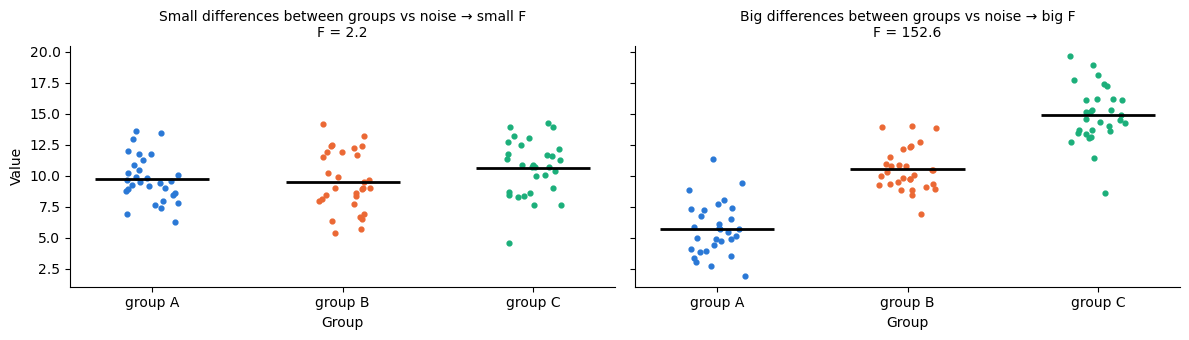

In [2]:
np.random.seed(3)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, means, title in [
    (axes[0], [10, 10.2, 10.4], "Small differences between groups vs noise → small F"),
    (axes[1], [6, 10, 14], "Big differences between groups vs noise → big F"),
]:
    groups = [np.random.normal(m, 2, 30) for m in means]
    for i, (g, colour) in enumerate(zip(groups, [BLUE, ORANGE, GREEN])):
        ax.scatter(np.full(30, i) + np.random.uniform(-0.15, 0.15, 30), g, s=12, color=colour)
        ax.hlines(g.mean(), i - 0.3, i + 0.3, color="black", linewidth=2)
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
    f_value = stats.f_oneway(*groups).statistic
    ax.set_title(f"{title}\nF = {f_value:.1f}", fontsize=10)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["group A", "group B", "group C"])
    ax.set_xlabel("Group")
axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

Black lines are the group means. Same noise in both panels. On the left the means are close compared to the spread, on the right they are far apart.

---
## 3. Types of ANOVA

| Type | Factors | Levels are | Example |
|---|---|---|---|
| **One-way ANOVA** | 1 factor, ≥ 2 levels | independent (different people in each group) | Anxiety for doses 0 mg / 50 mg / 100 mg, different patients |
| **Repeated measures ANOVA** | 1 factor, ≥ 2 levels | dependent (same people measured several times) | Same runners timed on day 1, 2, 3 |
| **Factorial (two-way) ANOVA** | 2 or more factors | independent, dependent or mixed | Effect of dose **and** gender on anxiety |

A **factor** is the grouping variable (medicine dose). **Levels** are its values (0, 50, 100 mg). In this notebook we do one-way ANOVA.

---
## 4. One-way ANOVA by hand

**Example.** Researchers test an anxiety medicine. 21 people are split into 3 groups (0 mg, 50 mg, 100 mg) and rate their anxiety from 1 to 10. Are there differences between the doses? α = 0.05.

| 0 mg | 50 mg | 100 mg |
|---|---|---|
| 9 | 7 | 4 |
| 8 | 6 | 3 |
| 7 | 6 | 2 |
| 8 | 7 | 3 |
| 8 | 8 | 4 |
| 9 | 7 | 3 |
| 8 | 6 | 2 |

### Step 1 and 2: hypotheses and α

- H₀: $\mu_{0mg} = \mu_{50mg} = \mu_{100mg}$
- H₁: not all means are equal
- α = 0.05

### Step 3: degrees of freedom

With a = 3 groups, n = 7 per group, N = 21 in total:

- df between = a − 1 = **2**
- df within = N − a = **18**
- df total = N − 1 = **20**

### Step 4: decision rule

F-table at α = 0.05 with (2, 18) degrees of freedom → **3.555**. If F > 3.555, reject H₀.

(F is a ratio of two variances, so it is never negative. Only the right tail is used.)

### Step 5: calculate F

**Formulas**

$$SS_{between} = \sum_{j} n_j (\bar{x}_j - \bar{x})^2 \qquad SS_{within} = \sum_{j} \sum_{i} (x_{ij} - \bar{x}_j)^2$$

$$MS = \frac{SS}{df} \qquad\qquad F = \frac{MS_{between}}{MS_{within}}$$

| Symbol | Meaning |
|---|---|
| $\bar{x}_j$ | mean of group j |
| $\bar{x}$ | grand mean (all 21 values) |
| $n_j$ | size of group j |
| SS | sum of squares (a total of squared distances) |
| MS | mean square (SS divided by its df, a variance) |

**Manual calculation**

Group sums: 57, 47, 21. Group means: 57/7 = **8.143**, 47/7 = **6.714**, 21/7 = **3.000**. Grand mean = 125/21 = **5.952**.

**Between:**

$SS_{between} = 7(8.143 - 5.952)^2 + 7(6.714 - 5.952)^2 + 7(3.000 - 5.952)^2$
$= 7(4.800) + 7(0.581) + 7(8.716) = 33.60 + 4.07 + 61.01 = \mathbf{98.67}$

**Within** (squared distances from each group's own mean):

- 0 mg: (0.857² + 0.143² + 1.143² + 0.143² + 0.143² + 0.857² + 0.143²) = 2.857
- 50 mg: (0.286² + 0.714² + 0.714² + 0.286² + 1.286² + 0.286² + 0.714²) = 3.429
- 100 mg: (1² + 0² + 1² + 0² + 1² + 0² + 1²) = 4.000

$SS_{within} = 2.857 + 3.429 + 4.000 = \mathbf{10.29}$

**ANOVA table**

| Source | SS | df | MS = SS / df | F |
|---|---|---|---|---|
| Between | 98.67 | 2 | 49.33 | 49.33 / 0.571 = **86.3** |
| Within | 10.29 | 18 | 0.571 | |
| Total | 108.95 | 20 | | |

### Step 6: decision

86.3 > 3.555 → $\color{red}{\textbf{reject } H_0}$. The dose makes a difference to anxiety.

In [3]:
dose_0 = [9, 8, 7, 8, 8, 9, 8]
dose_50 = [7, 6, 6, 7, 8, 7, 6]
dose_100 = [4, 3, 2, 3, 4, 3, 2]
groups = [dose_0, dose_50, dose_100]

all_values = np.concatenate(groups)
grand_mean = all_values.mean()

ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
ss_within = sum(((np.array(g) - np.mean(g)) ** 2).sum() for g in groups)

a = len(groups)
N = len(all_values)
df_between = a - 1
df_within = N - a

ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_by_hand = ms_between / ms_within

anova_table = pd.DataFrame({
    "SS": [ss_between, ss_within, ss_between + ss_within],
    "df": [df_between, df_within, N - 1],
    "MS": [ms_between, ms_within, np.nan],
    "F": [f_by_hand, np.nan, np.nan],
}, index=["Between", "Within", "Total"]).round(3)
anova_table

,SS,df,MS,F
Between,98.667,2,49.333,86.333
Within,10.286,18,0.571,NaN
Total,108.952,20,NaN,NaN


In [4]:
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html
f_critical = stats.f.ppf(0.95, df_between, df_within)
p_by_hand = 1 - stats.f.cdf(f_by_hand, df_between, df_within)
print(f"F critical (2, 18) = {f_critical:.3f}")
print(f"F = {f_by_hand:.2f}, p = {p_by_hand:.2e}")
print()
print("scipy f_oneway:", stats.f_oneway(dose_0, dose_50, dose_100))

F critical (2, 18) = 3.555
F = 86.33, p = 5.96e-10

scipy f_oneway: F_onewayResult(statistic=86.3333333333334, pvalue=5.956341358737431e-10)


> **Check:** Same F from the hand calculation and from scipy.

> **Note:** Where does the shortcut formula from textbooks come from? Many books write $SS_{between} = \frac{\sum (\sum x_j)^2}{n} - \frac{T^2}{N}$ with T = grand total. That's just an algebra trick to avoid computing means. With our numbers: $(57^2 + 47^2 + 21^2)/7 - 125^2/21 = 842.71 - 744.05 = 98.67$, same answer.

---
## 5. ANOVA on real data: penguin body mass

Do the three penguin species have the same average body mass?

In [5]:
mass_summary = penguins.groupby("species")["body_mass_g"].agg(["count", "mean", "std"]).round(1)
mass_summary

,count,mean,std
species,,,
Adelie,146,3706.2,458.6
Chinstrap,68,3733.1,384.3
Gentoo,119,5092.4,501.5


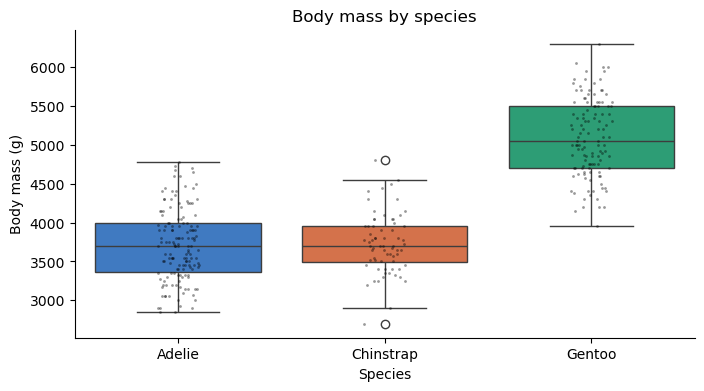

In [6]:
fig, ax = plt.subplots()
# docs: https://seaborn.pydata.org/generated/seaborn.boxplot.html
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="species", palette=SPECIES_COLOURS, legend=False, ax=ax)
sns.stripplot(data=penguins, x="species", y="body_mass_g", color="black", size=2, alpha=0.4, ax=ax)
ax.set_title("Body mass by species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
plt.show()

Gentoo looks clearly heavier. Adelie and Chinstrap look similar. Let's test.

- H₀: mean body mass is the same for all three species
- H₁: at least one species is different
- α = 0.05

In [7]:
adelie = penguins.loc[penguins["species"] == "Adelie", "body_mass_g"]
chinstrap = penguins.loc[penguins["species"] == "Chinstrap", "body_mass_g"]
gentoo = penguins.loc[penguins["species"] == "Gentoo", "body_mass_g"]

result = stats.f_oneway(adelie, chinstrap, gentoo)
print(f"F = {result.statistic:.1f}, p = {result.pvalue:.2e}")
print("df between = 2, df within =", len(penguins) - 3)

F = 341.9, p = 3.74e-81
df between = 2, df within = 330


**Result:** F is huge and p is basically 0 → $\color{red}{\text{reject } H_0}$. At least one species has a different average mass.

But ANOVA doesn't say **which one**. For that we need a post-hoc test (section 7). First, let's check the assumptions.

---
## 6. Checking the assumptions

One-way ANOVA assumes:

| Assumption | How to check | If it fails |
|---|---|---|
| Independent observations | Study design (each penguin measured once) | Use repeated measures ANOVA |
| Roughly normal data in each group | Q-Q plot or histogram per group (Shapiro-Wilk test for small groups) | With big groups the CLT helps. Otherwise use Kruskal-Wallis |
| Similar variances across groups | Levene's test, or rule of thumb: largest sd / smallest sd < 2 | Use Welch's ANOVA |

In [8]:
for name, group in [("Adelie", adelie), ("Chinstrap", chinstrap), ("Gentoo", gentoo)]:
    # docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html
    shapiro_p = stats.shapiro(group).pvalue
    print(f"{name:10s} n = {len(group):3d}  sd = {group.std():6.1f}  Shapiro-Wilk p = {shapiro_p:.3f}")

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html
levene = stats.levene(adelie, chinstrap, gentoo)
print(f"\nLevene's test for equal variances: p = {levene.pvalue:.3f}")
print(f"largest sd / smallest sd = {max(g.std() for g in [adelie, chinstrap, gentoo]) / min(g.std() for g in [adelie, chinstrap, gentoo]):.2f}")

Adelie     n = 146  sd =  458.6  Shapiro-Wilk p = 0.042
Chinstrap  n =  68  sd =  384.3  Shapiro-Wilk p = 0.561
Gentoo     n = 119  sd =  501.5  Shapiro-Wilk p = 0.261

Levene's test for equal variances: p = 0.006
largest sd / smallest sd = 1.30


**Reading this:**

- Shapiro-Wilk: H₀ = "the data is normal". Chinstrap and Gentoo look fine. Adelie gives a small p-value, but with 146 penguins even small deviations become "significant", and the CLT protects the group means anyway.
- Levene's test gives p = 0.006, so formally the variances are not equal. The difference is not dramatic (the sd ratio is only 1.3, below the rule-of-thumb limit of 2), but let's be careful and run two backup tests:
  - **Welch's ANOVA**, which does not assume equal variances
  - **Kruskal-Wallis**, a non-parametric test that does not assume normality (it works on ranks)

In [9]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.oneway.anova_oneway.html
welch = anova_oneway(penguins["body_mass_g"], groups=penguins["species"], use_var="unequal")
print(f"Welch's ANOVA : F = {welch.statistic:.1f}, p = {welch.pvalue:.2e}")

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
kruskal = stats.kruskal(adelie, chinstrap, gentoo)
print(f"Kruskal-Wallis: H = {kruskal.statistic:.1f}, p = {kruskal.pvalue:.2e}")

Welch's ANOVA : F = 316.5, p = 7.44e-61
Kruskal-Wallis: H = 212.1, p = 8.84e-47


All three tests (classic ANOVA, Welch, Kruskal-Wallis) reach the same conclusion. When different methods with different assumptions agree, we can be confident the result doesn't depend on the assumptions.

---
## 7. Post-hoc test: Tukey HSD

> **Theory.** After a significant ANOVA, the **Tukey HSD** (honestly significant difference) test compares every pair of groups, while keeping the overall false alarm rate at α. It solves exactly the "many t-tests" problem from section 1.

Read more: [Tukey's range test (Wikipedia)](https://en.wikipedia.org/wiki/Tukey%27s_range_test)

In [10]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html
tukey = pairwise_tukeyhsd(endog=penguins["body_mass_g"], groups=penguins["species"], alpha=0.05)
print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------


**Reading the table** (`meandiff` = group2 − group1, `reject` = significant or not):

| Pair | Mean difference | Decision |
|---|---|---|
| Adelie vs Chinstrap | about +27 g | $\color{green}{\text{fail to reject } H_0}$ |
| Adelie vs Gentoo | about +1,386 g | $\color{red}{\text{reject } H_0}$ |
| Chinstrap vs Gentoo | about +1,359 g | $\color{red}{\text{reject } H_0}$ |

So the ANOVA result is driven entirely by **Gentoo**, which is about 1.4 kg heavier. Adelie and Chinstrap have practically the same average mass. This matches what we saw in the box plot.

---
## 8. Effect size: η² (eta squared)

The p-value tells us the difference is real. **η²** tells us how **big** it is: the share of the total variation explained by the groups.

$$\eta^2 = \frac{SS_{between}}{SS_{total}}$$

Rough guide: 0.01 small, 0.06 medium, 0.14 large.

In [11]:
def eta_squared(groups):
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = ((all_values - grand_mean) ** 2).sum()
    return ss_between / ss_total

print(f"eta squared, anxiety example : {eta_squared([dose_0, dose_50, dose_100]):.2f}")
print(f"eta squared, penguin mass    : {eta_squared([adelie.to_numpy(), chinstrap.to_numpy(), gentoo.to_numpy()]):.2f}")

eta squared, anxiety example : 0.91
eta squared, penguin mass    : 0.67


Species explains about 67% of the variation in body mass, a very large effect. In the medicine example the dose explains about 91% (a textbook example, real data is rarely that clean).

---
## Summary

| Step | What we did |
|---|---|
| Question | Are 3+ group means equal? |
| Hypotheses | H₀: all equal. H₁: at least one differs |
| Statistic | F = MS between / MS within, df = (a − 1, N − a) |
| Decision | F > critical value, or p ≤ α → $\color{red}{\text{reject } H_0}$ |
| Assumptions | Independence, normality per group, equal variances |
| Backup test | Kruskal-Wallis (no normality needed), Welch's ANOVA (unequal variances) |
| Which groups? | Tukey HSD post-hoc test |
| How big? | η² = SS between / SS total |

## What's next

So far we compared groups. In notebook 10 we model how one number changes with another using **linear regression**, and in notebook 11 we predict yes/no outcomes with **logistic regression**.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), section 7.5 (comparing many means with ANOVA)
- [Analysis of variance, Wikipedia](https://en.wikipedia.org/wiki/Analysis_of_variance) · [One-way ANOVA, Wikipedia](https://en.wikipedia.org/wiki/One-way_analysis_of_variance)
- [Kruskal-Wallis test, Wikipedia](https://en.wikipedia.org/wiki/Kruskal%E2%80%93Wallis_test) · [Welch's ANOVA in statsmodels (`anova_oneway`)](https://www.statsmodels.org/stable/generated/statsmodels.stats.oneway.anova_oneway.html)
- [scipy `f_oneway`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html) · [statsmodels `pairwise_tukeyhsd`](https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html)